# Aprendizaje no supervisado

Los algoritmos que hemos visto pertenecen a un paradigma denominado "aprendizaje supervisado" y hace referencia al hecho de que es necesaria una base de datos **etiquetada por un experto** para que el algoritmo aprenda. En otras palabras, el algoritmo necesita la **supervisión** de un experto. 

Por otro lado, el "aprendizaje no supervisado" se refiere al paradigma de aprendizaje que no usa etiquetas de clase (por lo tanto estos algoritmos no pueden ser llamados clasificadores) sino que se basa en la similitud entre las muestras para tratar de encontrar los "agrupamientos naturales" que existan en la base de datos. Este paradigma también es llamado *clustering* y puede considerarse una estrategia descriptiva en lugar de predictiva, ya que se interesa en descubrir la estructura de los datos en lugar de aprender a diferenciarlos mediante un entrenamiento.

¿Cuántos agrupamientos "naturales" se podrían hacer en la siguiente imagen?

<img src="simpson.jpg" width=450/>

Por supuesto, los agrupamientos que hagamos están directamente relacionados con las características que extraigamos de los objetos. Pero aún teniendo unas características específicas, puede ser difícil definir cuáles agrupamientos describen los datos.

¿Cuántos *clusters* hay en los siguientes datos?

<img src="data_clusters.png" width=350/>

No hay una sola forma de ver el problema:

<img src="data_clusters2.png" width=800/>

Si esto fuera un problema de aprendizaje supervisado, podría provenir de varios escenarios:

<img src="data_clusters3.png" width=800/>


## Métodos jerárquicos

Los métodos jerárquicos son tal vez el los métodos más comúnmente usados para resumir la estructura de un conjunto de datos. Un árbol jerárquico es un conjunto anidado de particiones, representadas en un diagrama conocido como *dendrograma*.

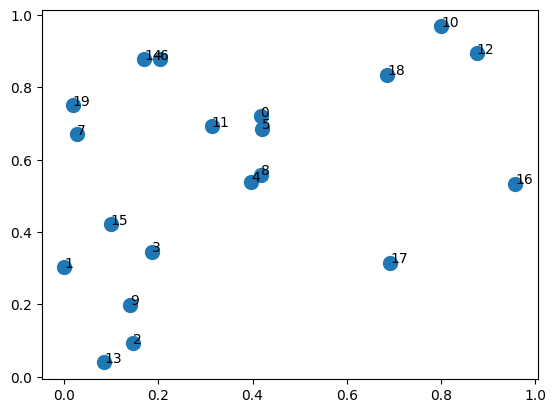

In [3]:
#Vamos a crear 20 muestras aleatorias de dos dimensiones
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(1)
X = np.random.rand(20, 2) # 20 muestras de dos dimensiones cada una
plt.scatter(X[:, 0], X[:, 1],s=100)
for i in range(len(X)):
    plt.annotate(i,X[i])

plt.show()

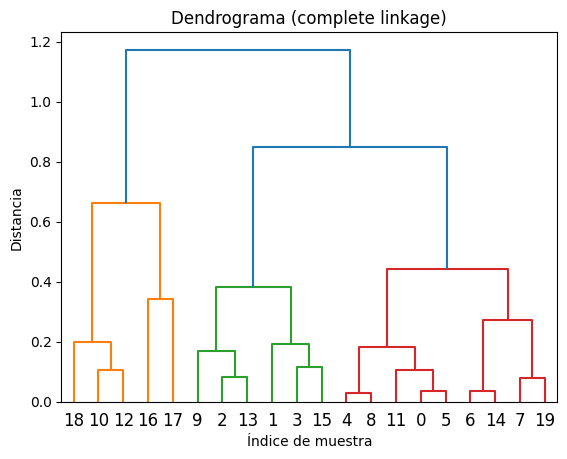

In [4]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

Z = sch.linkage(X, method='complete')

sch.dendrogram(Z)
plt.title("Dendrograma (complete linkage)")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia")
plt.show()

In [5]:
y = sch.fcluster(Z, t=0.6, criterion='distance')

print(y)

[4 3 3 3 4 4 4 4 4 3 1 4 1 3 4 3 2 2 1 4]


In [6]:
import pandas as pd

y=y-1; #Para que queden empezando encero
media_total=np.asmatrix(np.mean(X,axis=0)); #Media total
clases=pd.DataFrame(X).groupby(y)
medias=np.array(clases.mean()); #Matriz con las medias de cada clase
covarianzas=clases.cov();
ni=clases.size(); #Número de muestras de cada clase
SB=0
SW=0
for j in range(len(medias)):
    SB=SB+ni[j]/len(y)*(np.transpose(medias[j,:]-media_total).dot(medias[j,:]-media_total))
    Sigmai=covarianzas.loc[j]
    SW=SW+ni[j]/len(y)*(Sigmai)
J4=sum(np.diag(SB))/sum(np.diag(SW))
print(J4)

3.840023861200324


El agrupamiento de los datos se convierte entonces en un problema de escala una vez se tiene el correspondiente dendrograma. Seccionar el árbol a diferentes niveles, producirá diferentes clusters. Sin embargo, la forma de construir un dendrograma tampoco es única y se pueden usar diferentes criterios para construir las uniones, conocidos como **criterios de enlace**.

**Enlace sencillo**: La distancia entre dos grupos de muestras es igual a la **mínima** distancia entre las muestras de cada grupo.

**Enlace completo**: La distancia entre dos grupos de muestras es igual a la **máxima** distancia entre las muestras de cada grupo.

**Enlace promedio**: La distancia entre dos grupos de muestras es igual a la distancia entre los centroides de cada grupo.

<img src="linkages.png" width=800/>


In [8]:
#Veamos los diferentes dendrogramas que podemos construir con los mismos datos
import plotly.figure_factory as ff
import scipy.cluster.hierarchy as sch
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=3)
dend_single = ff.create_dendrogram(X,linkagefun=lambda x: sch.linkage(x, "single"))
dend_complete = ff.create_dendrogram(X,linkagefun=lambda x: sch.linkage(x, "complete"))
dend_average = ff.create_dendrogram(X,linkagefun=lambda x: sch.linkage(x, "average"))
#dend_single.update_layout(width=600, height=400)
dend_single.show(renderer="notebook_connected")
#dend_complete.update_layout(width=600, height=400)
dend_complete.show(renderer="notebook_connected")
#dend_average.update_layout(width=600, height=400)
dend_average.show(renderer="notebook_connected")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Métodos basados en centroides: Algoritmo k-medias

El algoritmo k-medias está basado en la mimnimización de la distancia intra-grupo para cada una de las agrupaciones. En su forma más simple, el algoritmo consta de tres pasos:

1. **Inicialización**: una vez escogido el número de grupos, k, se establecen k centroides en el espacio de los datos, por ejemplo, escogiéndolos aleatoriamente.
2. **Asignación objetos a los centroides**: cada objeto de los datos es asignado a su centroide más cercano.
3. **Actualización centroides**: se actualiza la posición del centroide de cada grupo tomando como nuevo centroide la posición del promedio de los objetos pertenecientes a dicho grupo.

<img src="kmeans.png" width=600/>

2
[1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0]


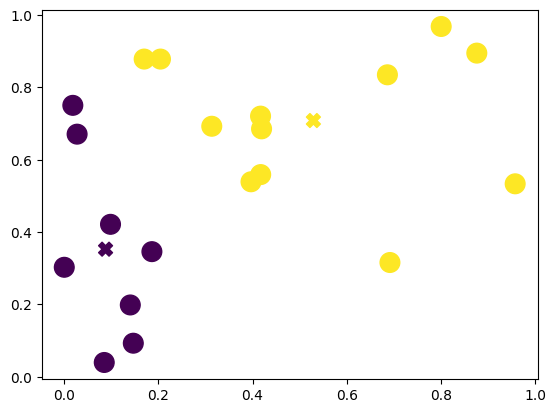

In [8]:
from scipy.spatial.distance import cdist

#Inicialización aleatoria de los centroides
k=2 #Número de centroides
pcent=np.random.choice(20,k)
centroides=X[pcent,:]

cond=0;
itera=0;
while(cond==0):
    itera=itera+1;
    D=cdist(centroides,X) #Se calculan las distancias de todas las muestras a los centroides
    clusters=np.argmin(D,axis=0)
    centroides_nuevos=np.zeros(np.shape(centroides))
    for i in range(k):
        centroides_nuevos[i,:]=np.mean(X[np.where(clusters==i)],axis=0)
    if np.linalg.norm(centroides - centroides_nuevos) < 1e-6:
        cond=1
    else: 
        centroides=centroides_nuevos

print(itera)
plt.scatter(X[:, 0], X[:, 1],c=clusters,s=200)
plt.scatter(centroides[:, 0], centroides[:, 1],c=range(k),s=100,marker='X')
print(clusters)

In [9]:
import pandas as pd
media_total=np.asmatrix(np.mean(X,axis=0)); #Media total
clases=pd.DataFrame(X).groupby(clusters)
medias=np.array(clases.mean()); #Matriz con las medias de cada clase
covarianzas=clases.cov();
ni=clases.size(); #Número de muestras de cada clase
SB=0
SW=0
for j in range(len(medias)):
    SB=SB+ni[j]/len(y)*(np.transpose(medias[j,:]-media_total).dot(medias[j,:]-media_total))
    Sigmai=covarianzas.loc[j]
    SW=SW+ni[j]/len(y)*(Sigmai)
J4=sum(np.diag(SB))/sum(np.diag(SW))
print(J4)

0.8369964745658535


## Métodos basados en grafos: Clustering espectral
 
El clustering espectral hace uso del espectro (valores propios) de la matriz de similitud de los datos para hacer una reducción de dimensiones y agrupar los datos en este espacio reducido. Para realizar el clustering espectral, definimos:

**Matriz de similitud (o adyacencia) A**: Es una matriz simétrica cuyo elemento $A_{ij}$ es la similitud entre el i-ésimo y el j-ésimo objeto de la base de datos.

**Matriz de grado D**: Es una matriz diagonal cuyos elementos cumplen
\begin{equation}
D_{ii} = \sum_{j} A_{ij}
\end{equation}

**Matriz Laplaciana**: Es una matriz cutos valores propios son siempre reales positivos (definida positiva) y sus vectores propios son ortogonales.
\begin{equation}
L = D-A
\end{equation}

**Matriz Laplaciana Normalizada**:
\begin{equation}
L_{rw}=D^{-1}L
\end{equation}

Una vez calculados los vectores propios de $L_rw$, se procede a realizar un clustering sobre la matriz con los primeros $n$ vectores propios, típicamente con k-medias.


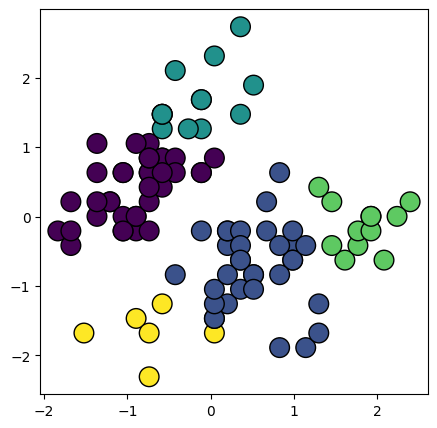

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

iris = datasets.load_iris()
X = iris.data[0:100, :2]
X = (X - X.mean(axis=0)) / X.std(axis=0)

dist=cdist(X,X) #Distancias
A = np.exp(-dist**2) #Similitudes

# Laplaciano no normalizado
D = np.diag(A.sum(axis=1))
L = D - A
Lrw = np.dot(np.linalg.inv(D),L)


# Espectral: k autovectores de menor autovalor
k = 5
w, V = np.linalg.eigh(Lrw)
U = V[:, np.argsort(w)[:k]]

# k-means en el embedding
clases = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(U)

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=clases, s=200, edgecolor='k')
plt.show()

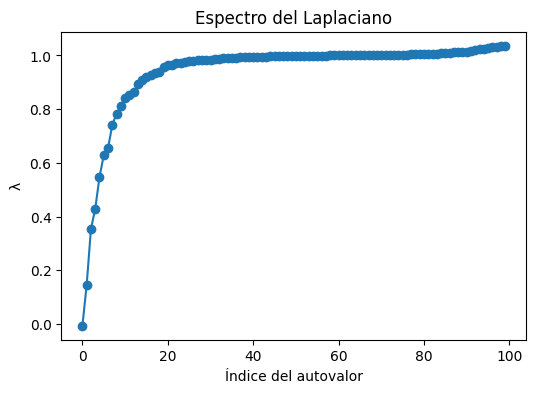

Número óptimo de clusters ≈ 2


In [11]:
import numpy as np
import matplotlib.pyplot as plt

w, V = np.linalg.eigh(Lrw)
w = np.real(w)
w.sort()

#Gráfica del espectro
plt.figure(figsize=(6,4))
plt.plot(w, 'o-')
plt.title('Espectro del Laplaciano')
plt.xlabel('Índice del autovalor')
plt.ylabel('λ')
plt.show()

# Brecha espectral
diffs = np.diff(w)
k_opt = np.argmax(diffs) + 1  #Brecha más grande
print("Número óptimo de clusters ≈", k_opt)

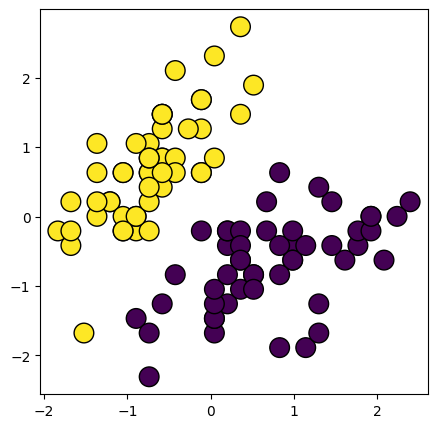

In [12]:
#Clusterin espectral usando el número óptimo de clusters

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

iris = datasets.load_iris()
X = iris.data[0:100, :2]
X = (X - X.mean(axis=0)) / X.std(axis=0)

dist=cdist(X,X) #Distancias
A = np.exp(-dist**2) #Similitudes

# Laplaciano no normalizado
D = np.diag(A.sum(axis=1))
L = D - A
Lrw = np.dot(np.linalg.inv(D),L)


# Espectral: k autovectores de menor autovalor
k = 2
w, V = np.linalg.eigh(Lrw)
U = V[:, np.argsort(w)[:k]]

# k-means en el embedding
clases = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(U)

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=clases, s=200, edgecolor='k')
plt.show()

7


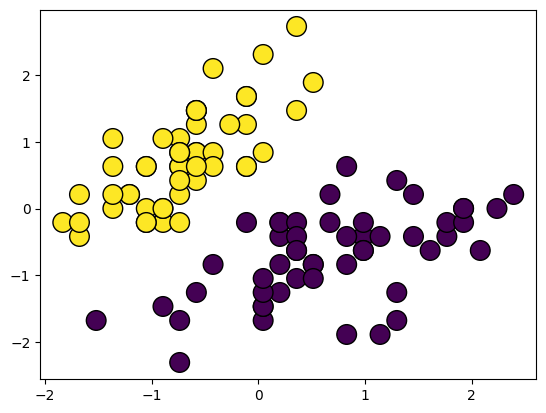

In [13]:
#K-medias usando el número óptimo de clusters

from scipy.spatial.distance import cdist

#Inicialización aleatoria de los centroides
k=2 #Número de centroides
pcent=np.random.choice(20,k)
centroides=X[pcent,:]

cond=0;
itera=0;
while(cond==0):
    itera=itera+1;
    D=cdist(centroides,X) #Se calculan las distancias de todas las muestras a los centroides
    clusters=np.argmin(D,axis=0)
    centroides_nuevos=np.zeros(np.shape(centroides))
    for i in range(k):
        centroides_nuevos[i,:]=np.mean(X[np.where(clusters==i)],axis=0)
    if np.linalg.norm(centroides - centroides_nuevos) < 1e-6:
        cond=1
    else: 
        centroides=centroides_nuevos

print(itera)
plt.scatter(X[:, 0], X[:, 1],c=clusters,s=200,edgecolor='k')


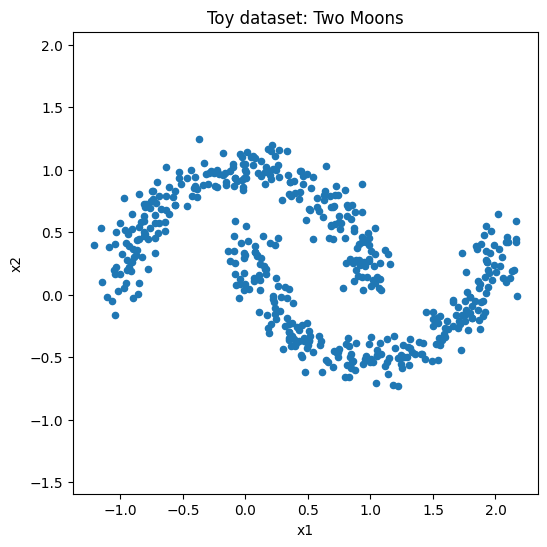

In [14]:
#Two Moons

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20)
plt.title("Toy dataset: Two Moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

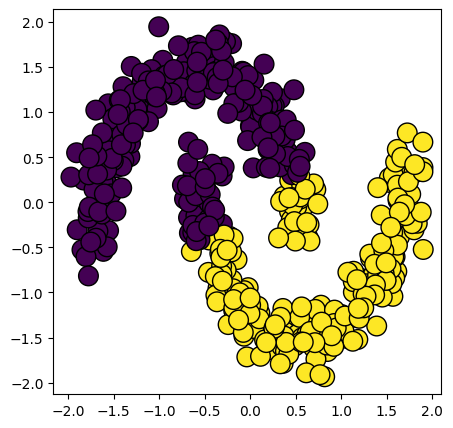

In [15]:
#Espectral

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

X=X_moons;
X = (X - X.mean(axis=0)) / X.std(axis=0)

dist=cdist(X,X) #Distancias
A = np.exp(-dist**2) #Similitudes

# Laplaciano no normalizado
D = np.diag(A.sum(axis=1))
L = D - A
Lrw = np.dot(np.linalg.inv(D),L)


# Espectral: k autovectores de menor autovalor
k = 2
w, V = np.linalg.eigh(Lrw)
U = V[:, np.argsort(w)[:k]]

# k-means en el embedding
clases = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(U)

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=clases, s=200, edgecolor='k')
plt.show()

5


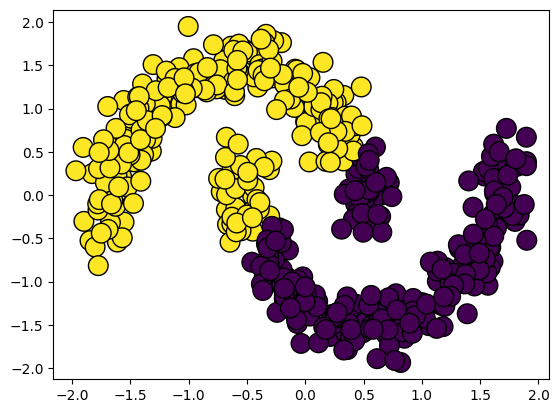

In [16]:
#K-medias

from scipy.spatial.distance import cdist

#Inicialización aleatoria de los centroides
k=2 #Número de centroides
pcent=np.random.choice(20,k)
centroides=X[pcent,:]

cond=0;
itera=0;
while(cond==0):
    itera=itera+1;
    D=cdist(centroides,X) #Se calculan las distancias de todas las muestras a los centroides
    clusters=np.argmin(D,axis=0)
    centroides_nuevos=np.zeros(np.shape(centroides))
    for i in range(k):
        centroides_nuevos[i,:]=np.mean(X[np.where(clusters==i)],axis=0)
    if np.linalg.norm(centroides - centroides_nuevos) < 1e-6:
        cond=1
    else: 
        centroides=centroides_nuevos

print(itera)
plt.scatter(X[:, 0], X[:, 1],c=clusters,s=200,edgecolor='k')

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN es un algoritmo de clustering basado en **densidad**, que agrupa puntos que están densamente conectados y separa regiones de baja densidad como ruido.

Un cluster es una región del espacio donde los puntos están **muy juntos (alta densidad)**, separados de otras regiones por zonas de baja densidad.

A diferencia de métodos como *k-means*, DBSCAN:

- No requiere especificar el número de clusters.
- Puede encontrar clusters de forma arbitraria (no convexos).
- Es robusto al ruido.


La Vecindad $\varepsilon$ de un punto $x$ se define como:
  
  $$
  N_\varepsilon(x) = \{y \mid d(x,y) \leq \varepsilon\}
  $$

Un punto $y$ es densamente alcanzable desde $x$ si existe una cadena de puntos núcleo que conecta $x$ con $y$.

Dos puntos pertenecen al mismo cluster si ambos son alcanzables desde algún punto núcleo común.



### Algoritmo:

- **$\varepsilon$ (eps)**: radio de vecindad.
- **min_samples**: número mínimo de puntos dentro del radio $\varepsilon$ para considerar que hay densidad suficiente.

Sea $D$ el conjunto de datos:

1. **Inicialización**  
   - Marcar todos los puntos como *no visitados*.  
   - Inicializar el contador de clusters $C = 0$.

2. **Iteración sobre los puntos**  
   Para cada punto $x \in D$:

   - Si $x$ ya fue visitado, continuar con el siguiente.
   - Marcar $x$ como *visitado*.
   - Calcular su vecindad $N_\varepsilon(x)$.

3. **Clasificación del punto**

   - Si $|N_\varepsilon(x)| < \text{min\_samples}$:
     - Marcar $x$ como **ruido** (temporalmente).
   
   - Si $|N_\varepsilon(x)| \geq \text{min\_samples}$:
     - $x$ es un **punto núcleo**.
     - Crear un nuevo cluster: $C = C + 1$.
     - Asignar $x$ al cluster $C$.
     - Inicializar una lista (cola) con los puntos de $N_\varepsilon(x)$.

4. **Expansión del cluster**

   Mientras la lista no esté vacía:

   - Tomar un punto $y$ de la lista.
   
   - Si $y$ no ha sido visitado:
     - Marcar $y$ como visitado.
     - Calcular $N_\varepsilon(y)$.
     
     - Si $|N_\varepsilon(y)| \geq \text{min\_samples}$:
       - $y$ también es núcleo → **agregar sus vecinos a la lista**  
         (esto es lo que permite la expansión por densidad).

   - Si $y$ no pertenece aún a ningún cluster:
     - Asignarlo al cluster $C$.


En 2014, el algoritmo fue merecedor del premio a la prueba del tiempo (un reconocimiento dado a algoritmos que han recibido una sustancial atención en la teoría y la práctica) en la conferencia líder de la minería de datos, KDD.

Clusters encontrados: 2
Puntos marcados como ruido: 0


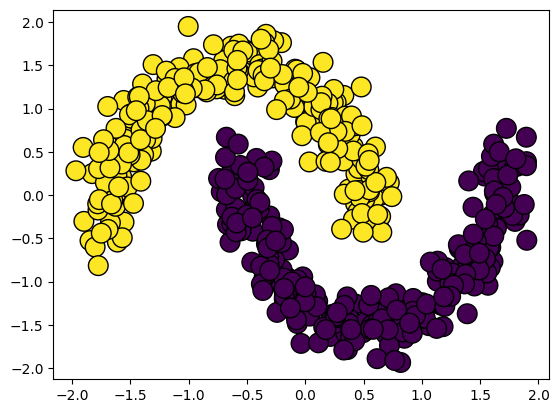

In [17]:
#DBSCAN

from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Ajustar DBSCAN sobre X_moons
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X_moons)

# Número de clusters encontrados (sin contar ruido = -1)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = np.sum(clusters == -1)

print("Clusters encontrados:", n_clusters)
print("Puntos marcados como ruido:", n_noise)

# Visualización
plt.scatter(X[:, 0], X[:, 1],c=clusters,s=200,edgecolor='k')